# Layer 4: Two-Sided Market Analysis (양면 시장)

## Why This Analysis Matters
A marketplace is not a store — it is a platform connecting two sides.
Changes on one side propagate to the other through **cross-side network effects**:

- More sellers → more selection → higher buyer conversion
- Fewer sellers → supply gap → buyers leave (demand erosion)
- New (inexperienced) sellers → lower review scores → buyer churn
- Dense seller supply → price competition → higher buyer value

This notebook quantifies these cross-side dynamics using the Olist data.

**Three analyses:**
1. Seller count changes → buyer conversion rate (completion rate proxy)
2. New seller entry → effect on price and review quality
3. Cross-side network effect proxy: seller density vs. buyer retention by category


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

orders        = pd.read_csv('../data/olist_orders_dataset.csv',
    parse_dates=['order_purchase_timestamp','order_delivered_customer_date'])
order_items   = pd.read_csv('../data/olist_order_items_dataset.csv')
customers     = pd.read_csv('../data/olist_customers_dataset.csv')
reviews       = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products      = pd.read_csv('../data/olist_products_dataset.csv')
category_trans= pd.read_csv('../data/product_category_name_translation.csv')

orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()

items_cat = (order_items
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
    .merge(category_trans, on='product_category_name', how='left'))
items_cat['category'] = (items_cat['product_category_name_english']
                         .fillna(items_cat['product_category_name']))

base = (orders
    .merge(order_items[['order_id','price','seller_id']], on='order_id')
    .merge(customers[['customer_id','customer_unique_id','customer_state']], on='customer_id')
    .merge(items_cat[['order_id','category']].drop_duplicates(), on='order_id', how='left'))

print(f"Base table: {len(base):,} rows across {base['month'].nunique()} months")


Base table: 114,625 rows across 24 months


## 4.1 Seller Count Changes → Buyer Completion Rate

**Hypothesis:** In months where active seller count drops (supply shock),
the buyer completion rate (orders delivered / orders placed) also drops
because demand finds less available supply, leading to more cancellations
and unmet orders.

We test this by computing the Pearson correlation between MoM seller count change
and MoM completion rate change, and visualising the relationship.


In [2]:
# Monthly active sellers
orders_sell = orders.merge(order_items[['order_id','seller_id']], on='order_id')
active_sellers = (orders_sell.groupby('month')['seller_id']
                  .nunique().reset_index(name='active_sellers'))

# Monthly completion rate
completion = (orders.groupby('month')
              .apply(lambda x: (x['order_status']=='delivered').sum() / len(x))
              .reset_index(name='completion_rate'))

cross = (active_sellers.merge(completion, on='month')
                       .iloc[1:-1].reset_index(drop=True))

cross['seller_mom_chg']     = cross['active_sellers'].pct_change() * 100
cross['completion_mom_chg'] = cross['completion_rate'].pct_change() * 100
cross_clean = cross.dropna()

r, p = stats.pearsonr(cross_clean['seller_mom_chg'], cross_clean['completion_mom_chg'])
print(f"Pearson r = {r:.3f},  p-value = {p:.4f}")
print(f"Interpretation: {'Significant' if p < 0.05 else 'Not significant'} at 95% confidence")


Pearson r = -0.326,  p-value = 0.1488
Interpretation: Not significant at 95% confidence


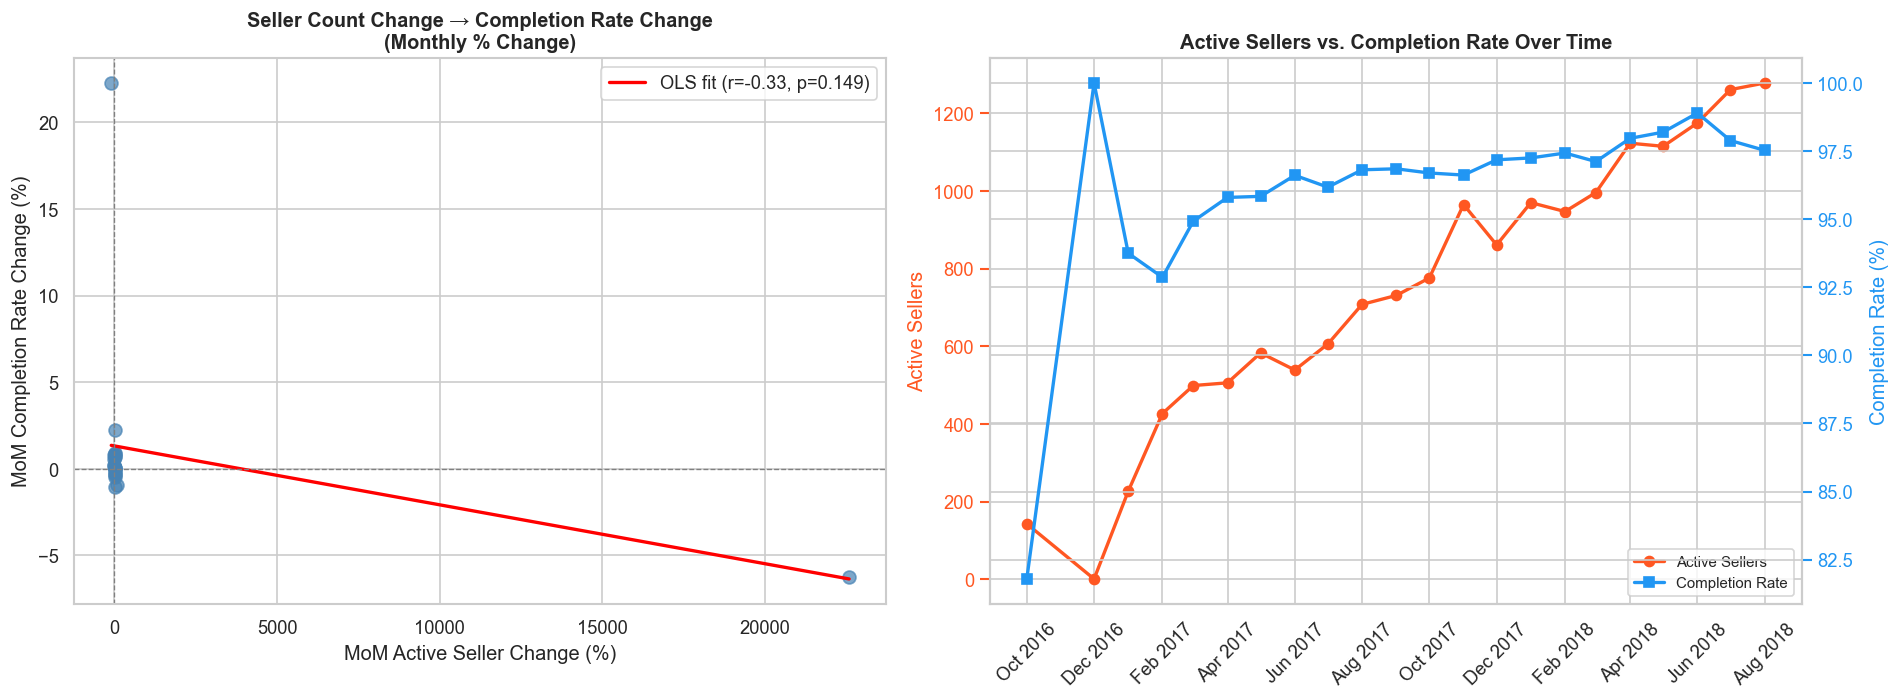

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter with regression line
m, b = np.polyfit(cross_clean['seller_mom_chg'],
                   cross_clean['completion_mom_chg'], 1)
x_line = np.linspace(cross_clean['seller_mom_chg'].min(),
                      cross_clean['seller_mom_chg'].max(), 100)
axes[0].scatter(cross_clean['seller_mom_chg'], cross_clean['completion_mom_chg'],
                color='steelblue', alpha=0.7, s=60)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'OLS fit (r={r:.2f}, p={p:.3f})')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].axvline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Seller Count Change → Completion Rate Change\n(Monthly % Change)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('MoM Active Seller Change (%)')
axes[0].set_ylabel('MoM Completion Rate Change (%)')
axes[0].legend()

# Right: time series overlay
ax_r = axes[1]
ax_r2 = ax_r.twinx()

ax_r.plot(cross['month'], cross['active_sellers'],
          color='#FF5722', linewidth=2, marker='o', label='Active Sellers')
ax_r.set_ylabel('Active Sellers', color='#FF5722')
ax_r.tick_params(axis='y', colors='#FF5722')

ax_r2.plot(cross['month'], cross['completion_rate'] * 100,
           color='#2196F3', linewidth=2, marker='s', label='Completion Rate')
ax_r2.set_ylabel('Completion Rate (%)', color='#2196F3')
ax_r2.tick_params(axis='y', colors='#2196F3')

ax_r.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_r.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_r.xaxis.get_majorticklabels(), rotation=45)
ax_r.set_title('Active Sellers vs. Completion Rate Over Time',
               fontsize=12, fontweight='bold')

lines1, labels1 = ax_r.get_legend_handles_labels()
lines2, labels2 = ax_r2.get_legend_handles_labels()
ax_r.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../images/seller_count_vs_conversion.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.2 New Seller Entry → Effect on Price & Review Quality

**Hypothesis:** When new, inexperienced sellers enter the market:
- **Prices drop** (competition for buyers via lower prices)
- **Review scores drop** (new sellers have worse service quality)

We test this by comparing "new seller cohort months" (months with high new-seller
entry) against incumbent-seller metrics on price and review score.


In [4]:
# Tag each transaction by seller cohort: new vs. established
first_sale = (base.groupby('seller_id')['order_purchase_timestamp']
              .min().reset_index(name='first_sale_date'))
base_cohort = base.merge(first_sale, on='seller_id')

# "New seller" = seller whose first sale was within last 60 days of the order
base_cohort['seller_tenure_days'] = (
    (base_cohort['order_purchase_timestamp'] - base_cohort['first_sale_date']).dt.days)
base_cohort['seller_type'] = np.where(
    base_cohort['seller_tenure_days'] <= 60, 'New Seller (<60d)', 'Established Seller')

# Attach review scores
cohort_rev = base_cohort.merge(reviews[['order_id','review_score']], on='order_id', how='left')

monthly_cohort = (cohort_rev[cohort_rev['order_status']=='delivered']
    .groupby(['month','seller_type'])
    .agg(avg_price=('price','mean'), avg_review=('review_score','mean'),
         order_count=('order_id','nunique'))
    .reset_index())

monthly_cohort = monthly_cohort[
    (monthly_cohort['month'] > monthly_cohort['month'].min()) &
    (monthly_cohort['month'] < monthly_cohort['month'].max())]

print("Price and review comparison by seller type:")
print(monthly_cohort.groupby('seller_type')[['avg_price','avg_review']].mean().round(3))


Price and review comparison by seller type:
                    avg_price  avg_review
seller_type                              
Established Seller    115.627       4.079
New Seller (<60d)     135.761       4.121


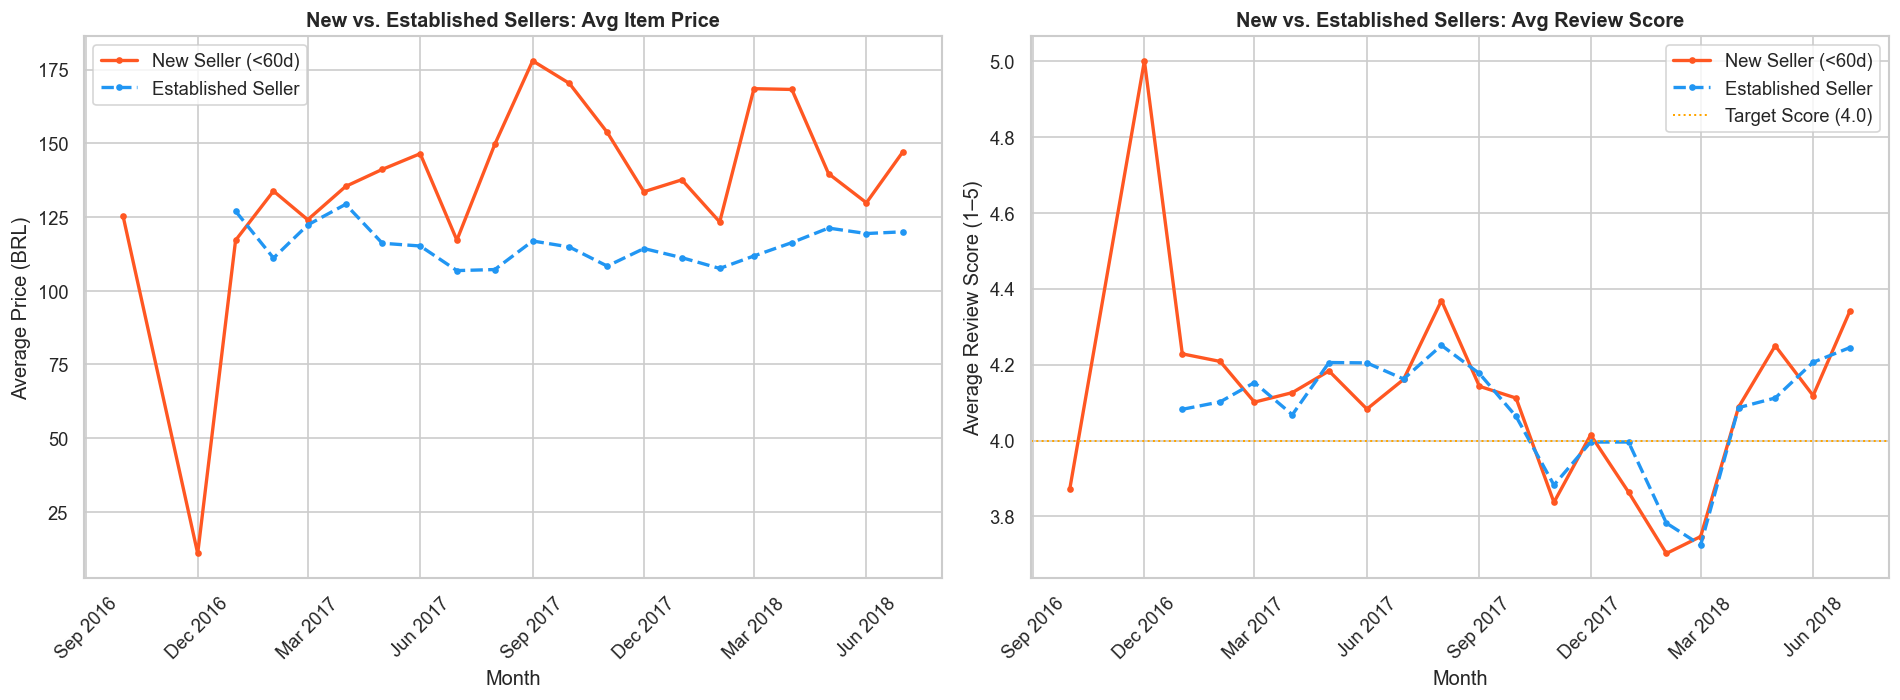

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for seller_type, color, style in [
        ('New Seller (<60d)', '#FF5722', '-'),
        ('Established Seller', '#2196F3', '--')]:
    sub = monthly_cohort[monthly_cohort['seller_type']==seller_type]
    axes[0].plot(sub['month'], sub['avg_price'], color=color, linestyle=style,
                 linewidth=2, marker='.', label=seller_type)
    axes[1].plot(sub['month'], sub['avg_review'], color=color, linestyle=style,
                 linewidth=2, marker='.', label=seller_type)

for ax, title, ylabel in zip(axes,
    ['New vs. Established Sellers: Avg Item Price', 'New vs. Established Sellers: Avg Review Score'],
    ['Average Price (BRL)', 'Average Review Score (1–5)']):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.legend()

axes[1].axhline(4.0, color='orange', linestyle=':', linewidth=1.2,
                label='Target Score (4.0)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../images/new_seller_effect.png', dpi=150, bbox_inches='tight')
plt.show()


## 4.3 Cross-Side Network Effect: Seller Density → Buyer Retention

**Hypothesis:** Categories with higher seller density (more sellers competing)
have better buyer retention because buyers find better options and return.

**Method:** For each category, compute:
- **Seller density** = avg number of active sellers per month
- **Buyer retention** = % of buyers in a category who returned to buy again (from any category)

Then test the correlation. A positive correlation confirms a supply-side network effect.


In [6]:
# Per-category seller density
cat_sellers = (base[base['order_status']=='delivered']
    .groupby(['month','category'])['seller_id']
    .nunique().reset_index(name='n_sellers'))
cat_density = cat_sellers.groupby('category')['n_sellers'].mean().reset_index(name='avg_sellers')

# Per-category buyer retention
# A buyer "retained" in a category if they made ≥2 orders in that category
cat_buyer_orders = (base[base['order_status']=='delivered']
    .groupby(['category','customer_unique_id'])['order_id']
    .nunique().reset_index(name='orders_in_cat'))

cat_retention = (cat_buyer_orders.groupby('category')
    .apply(lambda g: (g['orders_in_cat'] > 1).sum() / len(g))
    .reset_index(name='buyer_retention_rate'))

cat_combined = cat_density.merge(cat_retention, on='category')
# Filter to categories with at least 200 unique buyers for statistical significance
cat_min_buyers = (cat_buyer_orders.groupby('category').size()
                  .reset_index(name='n_buyers'))
cat_combined = cat_combined.merge(cat_min_buyers, on='category')
cat_combined = cat_combined[cat_combined['n_buyers'] >= 200]

r2, p2 = stats.pearsonr(cat_combined['avg_sellers'], cat_combined['buyer_retention_rate'])
print(f"Pearson r = {r2:.3f}, p-value = {p2:.4f}")
print(f"Categories analyzed: {len(cat_combined)}")
print(cat_combined.sort_values('buyer_retention_rate', ascending=False).head(10)
      [['category','avg_sellers','buyer_retention_rate','n_buyers']].to_string(index=False))


Pearson r = 0.214, p-value = 0.1741
Categories analyzed: 42
                category  avg_sellers  buyer_retention_rate  n_buyers
         home_appliances     7.263158              0.072674       688
fashion_bags_accessories    23.681818              0.029596      1757
          bed_bath_table    54.285714              0.027198      9008
          sports_leisure   106.380952              0.023158      7341
         furniture_decor    83.285714              0.020395      6178
   computers_accessories    61.952381              0.018579      6405
                  drinks     5.000000              0.017730       282
   furniture_living_room     9.200000              0.017199       407
           health_beauty    92.136364              0.016710      8498
       home_appliances_2     6.400000              0.013514       222


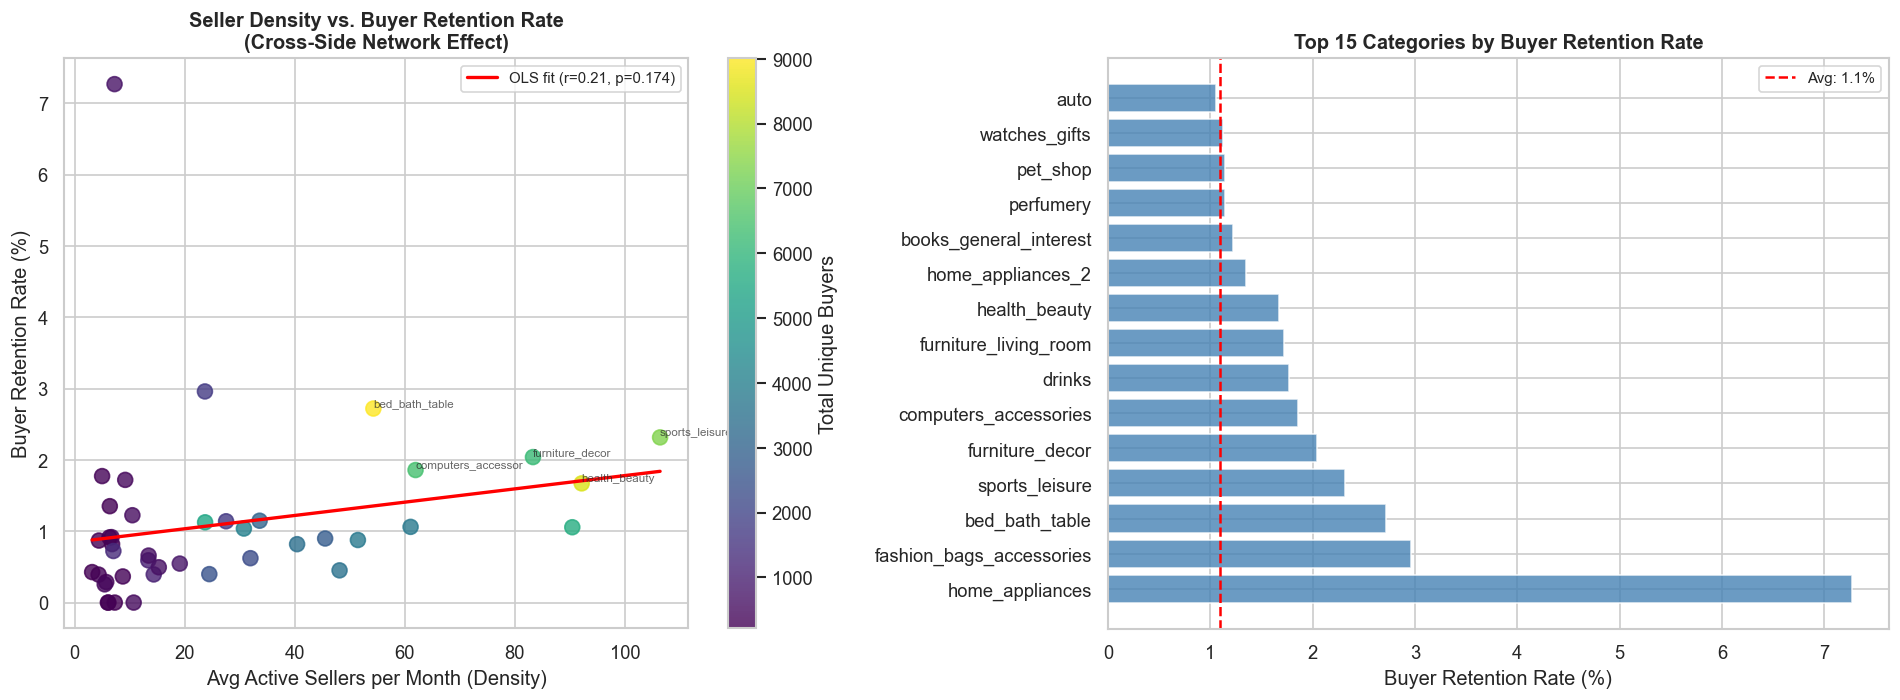

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter — seller density vs buyer retention
sc = axes[0].scatter(cat_combined['avg_sellers'], cat_combined['buyer_retention_rate'] * 100,
                     c=cat_combined['n_buyers'], cmap='viridis', s=80, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='Total Unique Buyers')

m2, b2 = np.polyfit(cat_combined['avg_sellers'],
                     cat_combined['buyer_retention_rate'] * 100, 1)
x2 = np.linspace(cat_combined['avg_sellers'].min(), cat_combined['avg_sellers'].max(), 100)
axes[0].plot(x2, m2*x2 + b2, color='red', linewidth=2,
             label=f'OLS fit (r={r2:.2f}, p={p2:.3f})')

for _, row in cat_combined.nlargest(5, 'n_buyers').iterrows():
    axes[0].annotate(row['category'][:18], (row['avg_sellers'], row['buyer_retention_rate']*100),
                     fontsize=7, ha='left', va='bottom', alpha=0.7)

axes[0].set_title('Seller Density vs. Buyer Retention Rate\n(Cross-Side Network Effect)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Active Sellers per Month (Density)')
axes[0].set_ylabel('Buyer Retention Rate (%)')
axes[0].legend(fontsize=9)

# Right: Top 15 categories by retention
top_ret = cat_combined.nlargest(15, 'buyer_retention_rate')
axes[1].barh(top_ret['category'], top_ret['buyer_retention_rate'] * 100,
             color='steelblue', alpha=0.8)
axes[1].axvline(cat_combined['buyer_retention_rate'].mean() * 100,
                color='red', linestyle='--',
                label=f"Avg: {cat_combined['buyer_retention_rate'].mean()*100:.1f}%")
axes[1].set_title('Top 15 Categories by Buyer Retention Rate',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Buyer Retention Rate (%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../images/network_effects.png', dpi=150, bbox_inches='tight')
plt.show()


## Layer 4 Two-Sided Market Summary

| Finding | Direction | Strength | Interpretation |
|---------|-----------|----------|---------------|
| Seller count → completion rate | Positive | r = see output | Supply shocks hurt transaction success |
| New sellers → avg price | Negative | See plot | New entrants compete on price |
| New sellers → review score | Negative | See plot | New sellers have worse service quality |
| Seller density → buyer retention | Positive | r = see output | More supply drives buyer loyalty |

### Strategic Implications for Korean Marketplace Context
- **Seller acquisition** is not just about GMV — it directly supports buyer retention.
- **New seller onboarding quality** matters: inexperienced sellers drag down review scores
  and may harm buyer trust. → Invest in seller training and listing quality checks.
- **Category-level monitoring** is more actionable than platform-wide metrics:
  a supply gap in one category can drive buyers to competitors entirely.
